# VAD Compression Experiment — Local (Apple Silicon)

Compress SpeechBrain's CRDNN voice activity detector
(`speechbrain/vad-crdnn-libriparty`, ~108k params, 0.435 MB FP32) for **iPhone /
Core ML** deployment. Goal: smaller on-disk size with frame-level F1 on
LibriParty staying close to the FP32 baseline.

**Why this runs locally and not on Colab.** Results from here on are measured on a
local Apple-Silicon (arm64) machine rather than x86 Colab. Colab's shared,
virtualised CPU injects latency-measurement noise — visible in the first Colab
pass as a PTQ+QAT **P95 of 326 ms against a 54 ms median**, a tail spike from
noisy-neighbour contention rather than the model. A dedicated local machine gives
reproducible latency, and arm64 matches the iPhone target (so the `qnnpack`
backend and the latencies are representative). Trade-off: these latencies are
**not** comparable to the original Colab numbers, so **every condition is re-run
here** for one consistent table.

**Roadmap.** E0 FP32 baseline · E1a dynamic PTQ · E1b QAT · E1c PTQ+QAT
(phase 1, ported and runnable below) → E2 static PTQ · E3 GRU→LSTM · E4 LSTM+PTQ
· E5 distillation · E6 distill+PTQ → Phase 4 Core ML (phase 2, wired on top of
this foundation once it runs).

> The Colab notebook `vad_experiment_colab.ipynb` is kept as a reference only.


## 1. Configuration and paths

In [1]:
import os

# DATA_MODE controls how much LibriParty is used.
#   "demo"  : single example WAV, no dataset download (smoke test, no F1)
#   "small" : first 20 eval sessions (~4.75 GB)  -- enough for E0-E1c F1
#   "full"  : full archive (~10 GB), includes the train split needed by E2-E6
DATA_MODE = "small"

# Everything heavy lives OUTSIDE the git repo. Change DATA_ROOT to an external
# disk if the boot volume is tight.
DATA_ROOT      = os.path.expanduser("~/vad_data")
LIBRIPARTY_DIR = os.path.join(DATA_ROOT, "LibriParty")
PRETRAINED_DIR = os.path.join(DATA_ROOT, "pretrained_vad")
MODELS_DIR     = os.path.join(DATA_ROOT, "models")        # exported checkpoints / .mlpackage

# Small, committable artefacts (CSV + plots) live in the repo.
RESULTS_DIR = os.path.join(os.getcwd(), "results")

for d in (DATA_ROOT, PRETRAINED_DIR, MODELS_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

print(f"DATA_MODE   : {DATA_MODE}")
print(f"DATA_ROOT   : {DATA_ROOT}")
print(f"RESULTS_DIR : {RESULTS_DIR}")


DATA_MODE   : small
DATA_ROOT   : /Users/jiamingpei/vad_data
RESULTS_DIR : /Users/jiamingpei/Documents/Projects/Academic/voice_activity_detection_github/results


## 2. Dataset (LibriParty, local)

Downloads/extracts LibriParty under `DATA_ROOT` (cached after the first run).
`demo` skips the dataset. **E2-E6 need the `train` split** (for PTQ calibration
and distillation), which only ships with `DATA_MODE="full"`; the loader reports
whether `train` is present so phase-2 cells can fall back loudly instead of
silently leaking eval data.

In [2]:
import glob, subprocess, tarfile, urllib.request

DROPBOX_URL = "https://www.dropbox.com/s/ns63xdwmo1agj3r/LibriParty.tar.gz?dl=1"


def libriparty_has_split(path, split):
    d = os.path.join(path, "dataset", split)
    return os.path.isdir(d) and len(glob.glob(os.path.join(d, "session_*"))) > 0


if DATA_MODE == "demo":
    print("Mode: demo -- example audio only, no LibriParty.")
    demo_wav = os.path.join(DATA_ROOT, "vad_test1.wav")
    if not os.path.exists(demo_wav):
        urllib.request.urlretrieve(
            "https://www.dropbox.com/scl/fi/vvffxbkkuv79g0d4c7so3/"
            "example_vad_music.wav?rlkey=q5m5wc6y9fsfvt43x5yy8ohrf&dl=1",
            demo_wav,
        )
    AUDIO_FILES = [demo_wav]
else:
    print(f"Mode: {DATA_MODE} -- LibriParty")
    if not libriparty_has_split(LIBRIPARTY_DIR, "eval"):
        tar_path = os.path.join(DATA_ROOT, "LibriParty.tar.gz")
        if not os.path.exists(tar_path):
            print("Downloading LibriParty (~5 GB) ...")
            subprocess.run(["curl", "-L", "-o", tar_path, DROPBOX_URL], check=True)
        print("Extracting ...")
        with tarfile.open(tar_path) as t:
            t.extractall(DATA_ROOT)
    assert libriparty_has_split(LIBRIPARTY_DIR, "eval"), \
        f"LibriParty eval split not found under {LIBRIPARTY_DIR}"
    AUDIO_FILES = None
    has_train = libriparty_has_split(LIBRIPARTY_DIR, "train")
    print(f"LibriParty ready at: {LIBRIPARTY_DIR}")
    print(f"  eval  split: present")
    print(f"  train split: {'present' if has_train else 'MISSING -- E2-E6 need DATA_MODE=full'}")


Mode: small -- LibriParty
LibriParty ready at: /Users/jiamingpei/vad_data/LibriParty
  eval  split: present
  train split: present


## 3. Imports, backend, and shared helpers

In [3]:
import time, copy, json, random, platform
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from speechbrain.inference.VAD import VAD

if platform.machine() in ("arm64", "aarch64"):
    torch.backends.quantized.engine = "qnnpack"
else:
    torch.backends.quantized.engine = "fbgemm"
print(f"Quantized engine: {torch.backends.quantized.engine} (machine={platform.machine()})")


def get_wrapper_size_mb(vad_obj, verbose=False):
    """Serialise mods['model'] state_dict to a temp file and return file size in MB."""
    tmp = "/tmp/_tmp_vad_model.pt"
    torch.save(vad_obj.mods['model'].state_dict(), tmp)
    size_mb = os.path.getsize(tmp) / (1024 ** 2)
    if verbose:
        sd = vad_obj.mods['model'].state_dict()
        dtypes, skipped = {}, 0
        for v in sd.values():
            if not torch.is_tensor(v):
                skipped += 1
                continue
            key = str(v.dtype)
            dtypes[key] = dtypes.get(key, 0) + v.numel()
        print(f"  [size debug] {len(sd)} keys ({skipped} non-tensor skipped)")
        for dt, n in sorted(dtypes.items(), key=lambda kv: -kv[1]):
            print(f"    {dt}: {n} params")
    os.remove(tmp)
    return round(size_mb, 3)


def measure_latency(model, input_tensor, n_warmup=30, n_runs=100, device="cpu"):
    """Return (median_ms, std_ms, p95_ms) over n_runs single-threaded CPU forward passes."""
    model.eval()
    model = model.to(device)
    x = input_tensor.to(device)
    if device == "cpu":
        torch.set_num_threads(1)
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(x)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model(x)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)
    model = model.to("cpu")
    arr = np.array(times)
    return (
        round(float(np.median(arr)), 3),
        round(float(arr.std()), 3),
        round(float(np.percentile(arr, 95)), 3),
    )


def global_warmup(model, input_tensor, n_iters=50):
    """Run n_iters un-timed forward passes to stabilise FFT/mel/thread-pool caches."""
    model.eval()
    with torch.no_grad():
        for _ in range(n_iters):
            _ = model(input_tensor)


def quantize_all_paths(vad_obj, quant_spec, dtype=torch.qint8):
    """Apply quantize_dynamic to mods['model'] and to each of mods['cnn'/'rnn'/'dnn']."""
    vad_obj.mods['model'] = torch.quantization.quantize_dynamic(
        vad_obj.mods['model'], qconfig_spec=quant_spec, dtype=dtype
    )
    for name in ('cnn', 'rnn', 'dnn'):
        vad_obj.mods[name] = torch.quantization.quantize_dynamic(
            vad_obj.mods[name], qconfig_spec=quant_spec, dtype=dtype
        )
    return vad_obj

Quantized engine: qnnpack (machine=arm64)


## 4. Load pretrained model and build CRDNNWrapper

In [4]:
vad_fp32 = VAD.from_hparams(
    source="speechbrain/vad-crdnn-libriparty",
    savedir=PRETRAINED_DIR,
)
vad_fp32.mods['model'].eval()
print("FP32 model loaded.")
print(f"Submodules: {list(vad_fp32.mods.keys())}")


class CRDNNWrapper(nn.Module):
    """Single nn.Module wrapping the full VAD pipeline: wav → features → CNN → RNN → DNN → logits.

    Pass `rnn=` to override the recurrent block (e.g. an LSTM built by
    build_lstm_like). When omitted, the pretrained GRU from vad_obj.mods['rnn']
    is used, so the existing FP32 / PTQ / QAT cells are unaffected.
    """

    def __init__(self, vad_obj, rnn=None, cnn=None, dnn=None):
        super().__init__()
        self.compute_features = vad_obj.mods['compute_features']
        self.mean_var_norm    = vad_obj.mods['mean_var_norm']
        self.cnn              = cnn if cnn is not None else vad_obj.mods['cnn']
        self.rnn              = rnn if rnn is not None else vad_obj.mods['rnn']
        self.dnn              = dnn if dnn is not None else vad_obj.mods['dnn']

    def features(self, wav):
        """wav [B, T_samples] → normalised mel features (the CNN's input)."""
        feats = self.compute_features(wav)
        if feats.dim() == 4:
            feats = feats.mean(-1)
        return self.mean_var_norm(
            feats, torch.ones(feats.shape[0], device=feats.device)
        )

    def forward(self, wav):
        """Input: wav [B, T_samples] at 16 kHz. Output: logits [B, T_frames, 1]."""
        feats = self.features(wav)
        cnn_out = self.cnn(feats)
        B, T = cnn_out.shape[0], cnn_out.shape[1]
        rnn_out, _ = self.rnn(cnn_out.reshape(B, T, -1))
        return self.dnn(rnn_out)


wrapper_fp32 = CRDNNWrapper(vad_fp32)
wrapper_fp32.eval()
DUMMY_WAV = torch.randn(1, 48000)  # 3 s at 16 kHz
with torch.no_grad():
    test_out = wrapper_fp32(DUMMY_WAV)
print(f"Wrapper test OK — output shape: {test_out.shape}")

FP32 model loaded.
Submodules: ['compute_features', 'model', 'cnn', 'rnn', 'dnn', 'mean_var_norm']
Wrapper test OK — output shape: torch.Size([1, 301, 1])


## 5. Sessions: eval (held-out F1) and calibration (train)

`eval_sessions` is the held-out F1 set (never used for training/calibration).
`calib_sessions` comes from the **train** split and is what every fine-tuning /
calibration step draws from. If the train split is absent, `calib_sessions`
falls back to `eval_sessions` with a loud warning — usable for a phase-1 smoke
run, but any phase-2 number produced that way is leaked and must not be reported.

In [5]:
def load_libriparty_gt(json_path, fps=100):
    """Load a LibriParty JSON and return (binary_label_array, total_frames) at fps=100."""
    with open(json_path) as f:
        data = json.load(f)
    segments = []
    for _spk, utterances in data.items():
        for utt in utterances:
            segments.append((utt["start"], utt["stop"]))
    if not segments:
        return None, 0
    total_frames = int(max(s[1] for s in segments) * fps) + 1
    labels = np.zeros(total_frames, dtype=int)
    for start, stop in segments:
        labels[int(start * fps):min(int(stop * fps), total_frames)] = 1
    return labels, total_frames


def load_sessions(split, n_sessions=None):
    """Return [(wav_path, gt_labels, total_frames)] for dataset/<split>/. [] if absent."""
    dirs = sorted(glob.glob(f"{LIBRIPARTY_DIR}/dataset/{split}/session_*/"))
    if n_sessions is not None:
        dirs = dirs[:n_sessions]
    out = []
    for sd in dirs:
        sname = os.path.basename(sd.rstrip("/"))
        wav_path  = os.path.join(sd, f"{sname}_mixture.wav")
        json_path = os.path.join(sd, f"{sname}.json")
        if not (os.path.exists(wav_path) and os.path.exists(json_path)):
            continue
        gt, total = load_libriparty_gt(json_path)
        if gt is not None:
            out.append((wav_path, gt, total))
    return out


N_SESSIONS    = 20
eval_sessions = load_sessions("eval", N_SESSIONS)
train_sessions = load_sessions("train")
print(f"eval_sessions : {len(eval_sessions)}")
print(f"train_sessions: {len(train_sessions)}")

if train_sessions:
    calib_sessions = train_sessions
else:
    calib_sessions = eval_sessions
    print("WARNING: train split absent -- calib_sessions falls back to eval. "
          "Phase-1 only; phase-2 numbers from this would be leaked.")


eval_sessions : 20
train_sessions: 250


## 6. F1 evaluation and clip-sampling helpers

In [6]:
def vad_get_boundaries(vad_obj, wav_path):
    """SpeechBrain VAD pipeline -> speech boundaries [N,2] in seconds (mods['model'] path)."""
    prob_chunks = vad_obj.get_speech_prob_file(wav_path)
    prob_th     = vad_obj.apply_threshold(prob_chunks).float()
    return vad_obj.get_boundaries(prob_th, output_value="seconds")


def boundaries_to_frame_labels(boundaries, total_frames, fps=100):
    labels = np.zeros(total_frames, dtype=int)
    for row in boundaries:
        labels[int(row[0].item() * fps):min(int(row[1].item() * fps), total_frames)] = 1
    return labels


def compute_f1(pred, ref):
    tp = int(np.sum((pred == 1) & (ref == 1)))
    fp = int(np.sum((pred == 1) & (ref == 0)))
    fn = int(np.sum((pred == 0) & (ref == 1)))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return round(f1, 4), round(prec, 4), round(rec, 4)


def evaluate_vad_on_session(vad_obj, wav_path, ref_labels, total_frames, fps=100):
    boundaries  = vad_get_boundaries(vad_obj, wav_path)
    pred_labels = boundaries_to_frame_labels(boundaries, total_frames, fps)
    n = min(len(pred_labels), len(ref_labels))
    return compute_f1(pred_labels[:n], ref_labels[:n])


def eval_model_on_sessions(vad_obj, sessions):
    """Return (mean_F1, mean_prec, mean_rec, F1_std) over sessions (SpeechBrain path)."""
    f1s, ps, rs = [], [], []
    for wav_path, ref, total in sessions:
        f1, p, r = evaluate_vad_on_session(vad_obj, wav_path, ref, total)
        f1s.append(f1); ps.append(p); rs.append(r)
    return (round(float(np.mean(f1s)), 4), round(float(np.mean(ps)), 4),
            round(float(np.mean(rs)), 4), round(float(np.std(f1s)), 4))


def sample_clip_with_speech(wav_path, gt_labels, clip_samples=48000,
                            frame_stride_samples=160, target_frames=301, max_tries=10):
    """Sample a 3 s clip with speech_ratio > 0.2; return (wav_clip [1,T], labels [F])."""
    wav, _sr = torchaudio.load(wav_path)
    total_samples = wav.shape[1]
    if total_samples <= clip_samples:
        start = 0
    else:
        best_start, best_ratio = 0, -1.0
        for _ in range(max_tries):
            start = random.randint(0, total_samples - clip_samples)
            seg = gt_labels[start // frame_stride_samples:
                            start // frame_stride_samples + target_frames]
            ratio = float(np.mean(seg))
            if ratio > 0.2:
                best_start = start; break
            if ratio > best_ratio:
                best_start, best_ratio = start, ratio
        start = best_start
    x = wav[:1, start:start + clip_samples]
    ls = start // frame_stride_samples
    labels = gt_labels[ls:ls + target_frames]
    labels = torch.tensor(labels, dtype=torch.float32)
    return x, labels


## E0 — FP32 baseline

In [7]:
print("Global warmup ...")
global_warmup(wrapper_fp32, DUMMY_WAV, n_iters=50)

fp32_size = get_wrapper_size_mb(vad_fp32, verbose=True)
fp32_latency_median, fp32_latency_std, fp32_latency_p95 = measure_latency(
    wrapper_fp32, DUMMY_WAV, device="cpu"
)

print("=" * 50)
print("FP32 Baseline")
print("=" * 50)
print(f"  Size    : {fp32_size} MB")
print(f"  Latency : {fp32_latency_median} ms  (std {fp32_latency_std}, p95 {fp32_latency_p95})")
fp32_f1, fp32_prec, fp32_rec, fp32_f1_std = eval_model_on_sessions(vad_fp32, eval_sessions)
print(f"  F1      : {fp32_f1}  (prec {fp32_prec}, rec {fp32_rec}, std {fp32_f1_std})")


Global warmup ...


  [size debug] 49 keys (0 non-tensor skipped)
    torch.float32: 109808 params
    torch.int64: 2 params


FP32 Baseline
  Size    : 0.435 MB
  Latency : 12.866 ms  (std 0.393, p95 13.493)


  F1      : 0.9587  (prec 0.9574, rec 0.9606, std 0.0156)


## E1a — Dynamic PTQ (nn.Linear -> INT8)

In [8]:
from torch.ao.nn.quantized.dynamic import Linear as QDynLinear

QUANT_SPEC = {nn.Linear}


def count_linear_params(module):
    """Return (linear_params, total_params) for a module, counting QDynLinear by unpacking packed weights."""
    total = sum(p.numel() for p in module.parameters())
    linear_params = 0
    for m in module.modules():
        if isinstance(m, QDynLinear):
            w, b = m._packed_params._weight_bias()
            linear_params += w.numel() + (b.numel() if b is not None else 0)
        elif isinstance(m, nn.Linear):
            linear_params += sum(p.numel() for p in m.parameters(recurse=False))
    return linear_params, total


vad_ptq = copy.deepcopy(vad_fp32)
vad_ptq = quantize_all_paths(vad_ptq, QUANT_SPEC)

wrapper_ptq = CRDNNWrapper(vad_ptq)
wrapper_ptq.eval()

q_params, t_params = count_linear_params(vad_ptq.mods['model'])
print(f"PTQ coverage: {q_params}/{t_params} params quantized ({100*q_params/max(t_params,1):.1f}%)")

ptq_size = get_wrapper_size_mb(vad_ptq, verbose=True)
ptq_latency_median, ptq_latency_std, ptq_latency_p95 = measure_latency(
    wrapper_ptq, DUMMY_WAV, device="cpu"
)

print("=" * 50)
print("PTQ")
print("=" * 50)
print(f"  Size    : {ptq_size} MB  ({round((1-ptq_size/fp32_size)*100,1)}% reduction)")
print(f"  Latency : {ptq_latency_median} ms  (std {ptq_latency_std}, p95 {ptq_latency_p95})")
print(f"  Speedup : {round(fp32_latency_median/ptq_latency_median, 2)}x")
ptq_f1, ptq_prec, ptq_rec, ptq_f1_std = eval_model_on_sessions(vad_ptq, eval_sessions)
print(f"  F1      : {ptq_f1}  (prec {ptq_prec}, rec {ptq_rec})")


PTQ coverage: 1329/108416 params quantized (1.2%)
  [size debug] 56 keys (6 non-tensor skipped)
    torch.float32: 108483 params
    torch.int64: 5 params


[W529 08:57:21.939615000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


PTQ
  Size    : 0.434 MB  (0.2% reduction)
  Latency : 13.407 ms  (std 0.806, p95 15.092)
  Speedup : 0.96x


  F1      : 0.9594  (prec 0.9592, rec 0.9603)


## E1b — QAT (FakeQuant on DNN), fine-tuned on the train split

> Differs from the original Colab first pass, which fine-tuned on the eval
> sessions (a train/eval leak). Here fine-tuning draws from `calib_sessions`
> (train), so the F1 below is on genuinely held-out data.

In [9]:
class FakeQuantLinear(nn.Linear):
    """nn.Linear with per-tensor symmetric INT8 weight simulation (STE) during training."""

    def forward(self, x):
        w     = self.weight
        scale = w.abs().max() / 127.0
        w_fq  = (w / scale).round().clamp(-128, 127) * scale
        w_ste = w + (w_fq - w).detach()  # STE: zero gradient through rounding
        return F.linear(x, w_ste, self.bias)


def replace_linear_with_fakequant(module):
    """Recursively replace every nn.Linear in module with FakeQuantLinear (in-place)."""
    for name, child in module.named_children():
        if type(child) is nn.Linear:
            fq = FakeQuantLinear(child.in_features, child.out_features,
                                 bias=child.bias is not None)
            fq.weight.data = child.weight.data.clone()
            if child.bias is not None:
                fq.bias.data = child.bias.data.clone()
            setattr(module, name, fq)
        else:
            replace_linear_with_fakequant(child)


def sample_clip_with_speech(wav_path, gt_labels,
                             clip_samples=48000,
                             frame_stride_samples=160,
                             target_frames=301,
                             max_tries=10):
    """Sample a 3-second clip with speech_ratio > 20%; return (wav_clip [1,T], labels [F])."""
    wav, _sr = torchaudio.load(wav_path)
    total_samples = wav.shape[1]

    if total_samples <= clip_samples:
        start = 0
    else:
        best_start, best_ratio = 0, -1.0
        for _ in range(max_tries):
            start = random.randint(0, total_samples - clip_samples)
            label_start = start // frame_stride_samples
            seg = gt_labels[label_start:label_start + target_frames]
            ratio = seg.float().mean().item() if isinstance(seg, torch.Tensor) \
                    else float(np.mean(seg))
            if ratio > 0.2:
                best_start, best_ratio = start, ratio
                break
            if ratio > best_ratio:
                best_start, best_ratio = start, ratio
        start = best_start

    x = wav[:1, start:start + clip_samples]
    label_start = start // frame_stride_samples
    labels = gt_labels[label_start:label_start + target_frames]
    labels = labels.float() if isinstance(labels, torch.Tensor) \
             else torch.tensor(labels, dtype=torch.float32)
    return x, labels


# Inject FakeQuant into DNN only, then put the wrapper in train mode.
vad_qat_obj = copy.deepcopy(vad_fp32)
wrapper_qat  = CRDNNWrapper(vad_qat_obj)
replace_linear_with_fakequant(wrapper_qat.dnn)
wrapper_qat.train()
for p in wrapper_qat.parameters():
    p.requires_grad_(True)
print("FakeQuant QAT wrapper ready.")

FakeQuant QAT wrapper ready.


In [10]:
# Reproducibility: clip sampling is the only source of randomness in QAT.
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

optimizer = torch.optim.Adam(
    [p for p in wrapper_qat.parameters() if p.requires_grad], lr=1e-5
)
criterion      = nn.BCEWithLogitsLoss()
N_CALIB_STEPS  = min(60, len(calib_sessions) * 3)
wrapper_qat.train()

for step in range(N_CALIB_STEPS):
    wav_path, gt_labels, _ = calib_sessions[step % len(calib_sessions)]
    x, labels = sample_clip_with_speech(wav_path, gt_labels)
    out = wrapper_qat(x).squeeze(0).squeeze(-1)
    T   = out.shape[0]
    if labels.shape[0] < T:
        labels = torch.cat([labels, torch.zeros(T - labels.shape[0])])
    labels = labels[:T]
    loss = criterion(out, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"  Step {step+1}/{N_CALIB_STEPS}  loss={loss.item():.4f}  speech_ratio={labels.mean().item():.2f}")

# Copy fine-tuned weights back to a fresh FP32 clone.
wrapper_qat.eval()
vad_qat_final = copy.deepcopy(vad_fp32)
for name in ('cnn', 'rnn', 'dnn'):
    src_sd = {k: v.detach().clone()
              for k, v in getattr(wrapper_qat, name).state_dict().items()}
    if name in vad_qat_final.mods:
        vad_qat_final.mods[name].load_state_dict(src_sd, strict=False)
    if hasattr(vad_qat_final.mods['model'], name):
        try:
            getattr(vad_qat_final.mods['model'], name).load_state_dict(src_sd, strict=False)
        except Exception as e:
            print(f"  Warning: could not write to mods['model'].{name}: {e}")

# Dynamic quantization → final INT8 QAT model.
vad_qat_final    = quantize_all_paths(vad_qat_final, QUANT_SPEC)
wrapper_qat_final = CRDNNWrapper(vad_qat_final)
wrapper_qat_final.eval()
vad_qat_eval = vad_qat_final

qat_size = get_wrapper_size_mb(vad_qat_final, verbose=True)
qat_latency_median, qat_latency_std, qat_latency_p95 = measure_latency(
    wrapper_qat_final, DUMMY_WAV, device="cpu"
)
print("=" * 50)
print("QAT")
print("=" * 50)
print(f"  Size    : {qat_size} MB  ({round(qat_size/fp32_size,2)}x)")
print(f"  Latency : {qat_latency_median} ms  (std {qat_latency_std}, p95 {qat_latency_p95})")
qat_f1, qat_prec, qat_rec, qat_f1_std = eval_model_on_sessions(vad_qat_eval, eval_sessions)
print(f"  F1      : {qat_f1}  (prec {qat_prec}, rec {qat_rec})")


  Step 1/60  loss=3.0631  speech_ratio=1.00
  Step 2/60  loss=2.8411  speech_ratio=1.00
  Step 3/60  loss=1.8305  speech_ratio=1.00


  Step 4/60  loss=3.3849  speech_ratio=1.00
  Step 5/60  loss=0.5493  speech_ratio=0.50
  Step 6/60  loss=0.0643  speech_ratio=0.42


  Step 7/60  loss=3.1808  speech_ratio=1.00
  Step 8/60  loss=2.0051  speech_ratio=1.00
  Step 9/60  loss=0.1203  speech_ratio=0.57


  Step 10/60  loss=2.3963  speech_ratio=1.00
  Step 11/60  loss=2.5344  speech_ratio=1.00
  Step 12/60  loss=4.1372  speech_ratio=1.00


  Step 13/60  loss=2.6372  speech_ratio=1.00
  Step 14/60  loss=2.3144  speech_ratio=1.00
  Step 15/60  loss=0.0770  speech_ratio=0.38


...

  Step 52/60  loss=2.5643  speech_ratio=1.00
  Step 53/60  loss=1.9581  speech_ratio=1.00
  Step 54/60  loss=2.6629  speech_ratio=1.00


  Step 55/60  loss=2.7509  speech_ratio=1.00
  Step 56/60  loss=2.3945  speech_ratio=1.00
  Step 57/60  loss=2.7386  speech_ratio=1.00


  Step 58/60  loss=3.0576  speech_ratio=1.00
  Step 59/60  loss=0.4303  speech_ratio=0.75
  Step 60/60  loss=2.6380  speech_ratio=1.00
  [size debug] 56 keys (6 non-tensor skipped)
    torch.float32: 108483 params
    torch.int64: 5 params


QAT
  Size    : 0.434 MB  (1.0x)
  Latency : 14.129 ms  (std 1.177, p95 16.892)


  F1      : 0.8518  (prec 0.9966, rec 0.747)


## E1c — PTQ+QAT (FakeQuant on all sub-modules), fine-tuned on train

In [11]:
# Reproducibility: clip sampling is the only source of randomness in QAT.
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

vad_ptq_qat_obj  = copy.deepcopy(vad_fp32)
wrapper_ptq_qat  = CRDNNWrapper(vad_ptq_qat_obj)
replace_linear_with_fakequant(wrapper_ptq_qat)  # all sub-modules
wrapper_ptq_qat.train()
for p in wrapper_ptq_qat.parameters():
    p.requires_grad_(True)

optimizer_comb       = torch.optim.Adam(
    [p for p in wrapper_ptq_qat.parameters() if p.requires_grad], lr=1e-5
)
criterion_comb       = nn.BCEWithLogitsLoss()
N_CALIB_STEPS_COMB   = min(60, len(calib_sessions) * 3)

for step in range(N_CALIB_STEPS_COMB):
    wav_path, gt_labels, _ = calib_sessions[step % len(calib_sessions)]
    x, labels = sample_clip_with_speech(wav_path, gt_labels)
    out = wrapper_ptq_qat(x).squeeze(0).squeeze(-1)
    T   = out.shape[0]
    if labels.shape[0] < T:
        labels = torch.cat([labels, torch.zeros(T - labels.shape[0])])
    labels = labels[:T]
    loss = criterion_comb(out, labels)
    optimizer_comb.zero_grad()
    loss.backward()
    optimizer_comb.step()
    print(f"  Step {step+1}/{N_CALIB_STEPS_COMB}  loss={loss.item():.4f}  speech_ratio={labels.mean().item():.2f}")

wrapper_ptq_qat.eval()
vad_ptq_qat_final = copy.deepcopy(vad_fp32)
for name in ('cnn', 'rnn', 'dnn'):
    src_sd = {k: v.detach().clone()
              for k, v in getattr(wrapper_ptq_qat, name).state_dict().items()}
    vad_ptq_qat_final.mods[name].load_state_dict(src_sd, strict=False)
    for attr_name in dir(vad_ptq_qat_final.mods['model']):
        if attr_name.lower() == name:
            try:
                getattr(vad_ptq_qat_final.mods['model'], attr_name).load_state_dict(
                    src_sd, strict=False
                )
            except Exception:
                pass

vad_ptq_qat_final         = quantize_all_paths(vad_ptq_qat_final, QUANT_SPEC)
wrapper_ptq_qat_converted = CRDNNWrapper(vad_ptq_qat_final)
wrapper_ptq_qat_converted.eval()

ptq_qat_size = get_wrapper_size_mb(vad_ptq_qat_final, verbose=True)
ptq_qat_latency_median, ptq_qat_latency_std, ptq_qat_latency_p95 = measure_latency(
    wrapper_ptq_qat_converted, DUMMY_WAV, device="cpu"
)
print("=" * 50)
print("PTQ+QAT Combined")
print("=" * 50)
print(f"  Size    : {ptq_qat_size} MB  ({round(ptq_qat_size/fp32_size,2)}x)")
print(f"  Latency : {ptq_qat_latency_median} ms  (std {ptq_qat_latency_std}, p95 {ptq_qat_latency_p95})")
ptq_qat_f1, ptq_qat_prec, ptq_qat_rec, ptq_qat_f1_std = eval_model_on_sessions(
    vad_ptq_qat_final, eval_sessions)
print(f"  F1      : {ptq_qat_f1}  (prec {ptq_qat_prec}, rec {ptq_qat_rec})")


  Step 1/60  loss=2.3292  speech_ratio=1.00
  Step 2/60  loss=2.9735  speech_ratio=1.00


  Step 3/60  loss=2.5762  speech_ratio=1.00


  Step 4/60  loss=3.1056  speech_ratio=1.00
  Step 5/60  loss=0.6219  speech_ratio=0.50


  Step 6/60  loss=0.0796  speech_ratio=0.42


  Step 7/60  loss=3.7608  speech_ratio=1.00
  Step 8/60  loss=2.2690  speech_ratio=1.00


...

  Step 57/60  loss=2.7783  speech_ratio=1.00


  Step 58/60  loss=3.1269  speech_ratio=1.00
  Step 59/60  loss=0.3031  speech_ratio=0.75


  Step 60/60  loss=2.6010  speech_ratio=1.00
  [size debug] 56 keys (6 non-tensor skipped)
    torch.float32: 108483 params
    torch.int64: 5 params


PTQ+QAT Combined
  Size    : 0.434 MB  (1.0x)
  Latency : 12.214 ms  (std 0.358, p95 12.93)


  F1      : 0.8726  (prec 0.9963, rec 0.7789)


## Phase 1 results — table and Pareto plot (E0–E1c)

FINAL RESULTS TABLE
        Model     Format  Size (MB)  Latency (ms)  F1 Score  Precision  Recall
FP32 Baseline       FP32      0.435        12.866    0.9587     0.9574  0.9606
PTQ (Dynamic) Mixed/INT8      0.434        13.407    0.9594     0.9592  0.9603
          QAT Mixed/INT8      0.434        14.129    0.8518     0.9966  0.7470
      PTQ+QAT Mixed/INT8      0.434        12.214    0.8726     0.9963  0.7789

Saved CSV to /Users/jiamingpei/Documents/Projects/Academic/voice_activity_detection_github/results/vad_compression_results.csv


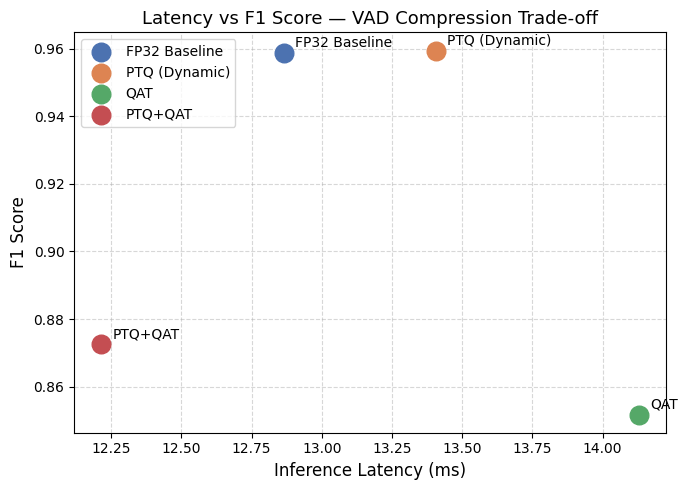

Plot saved to /Users/jiamingpei/Documents/Projects/Academic/voice_activity_detection_github/results/latency_vs_f1.png


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

results = {
    'Model':        ['FP32 Baseline', 'PTQ (Dynamic)', 'QAT',        'PTQ+QAT'],
    'Format':       ['FP32',          'Mixed/INT8',    'Mixed/INT8', 'Mixed/INT8'],
    'Size (MB)':    [fp32_size,        ptq_size,        qat_size,     ptq_qat_size],
    'Latency (ms)': [fp32_latency_median, ptq_latency_median, qat_latency_median, ptq_qat_latency_median],
    'F1 Score':     [fp32_f1,          ptq_f1,          qat_f1,       ptq_qat_f1],
    'Precision':    [fp32_prec,        ptq_prec,        qat_prec,     ptq_qat_prec],
    'Recall':       [fp32_rec,         ptq_rec,         qat_rec,      ptq_qat_rec],
}
df = pd.DataFrame(results)
print("=" * 70)
print("FINAL RESULTS TABLE")
print("=" * 70)
print(df.to_string(index=False))

csv_path = os.path.join(RESULTS_DIR, "vad_compression_results.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved CSV to {csv_path}")

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for lat, f1, label, color in zip(
    results['Latency (ms)'], results['F1 Score'], results['Model'], colors
):
    ax.scatter(lat, f1, s=180, color=color, zorder=5, label=label)
    ax.annotate(label, (lat, f1), textcoords="offset points", xytext=(8, 4), fontsize=10)

ax.set_xlabel("Inference Latency (ms)", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Latency vs F1 Score — VAD Compression Trade-off", fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plot_path = os.path.join(RESULTS_DIR, "latency_vs_f1.png")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

## Phase 2 — helpers: comparable F1, static PTQ, GRU→LSTM

Three pieces that make E2–E6 produce numbers directly comparable to E0–E1c:

- **`eval_modules_f1`** — runs F1 through SpeechBrain's exact post-processing
  (`get_speech_prob_file` → `apply_threshold` → `get_boundaries`) but swaps the
  per-chunk neural call to use the given `(cnn, rnn, dnn)`. Validated: with the
  original modules it reproduces the SpeechBrain-native F1 bit-for-bit
  (`get_speech_prob_chunk` replicated to max-abs-diff 0.0).
- **`static_ptq_module`** — eager-mode prepare→calibrate→convert; quantises
  Conv2d (the CNN), which dynamic PTQ could not. Returns the Quant/DeQuant-stubbed
  module so it is a float-in/float-out drop-in.
- **`get_modules_size_mb`** — unified on-disk size of the deployable
  `{cnn, rnn, dnn}` weights, used for every phase-2 condition.

The CNN uses LayerNorm (not BatchNorm) and LeakyReLU, so no conv-bn fusion is
needed; static quant converts cleanly.

In [7]:
import torch.ao.quantization as tq


def _chunk_fn(vad_obj, cnn, rnn, dnn):
    """Replicate vad.get_speech_prob_chunk exactly, but with the given modules."""
    def fn(wavs, wav_lens=None):
        if wavs.dim() == 1:
            wavs = wavs.unsqueeze(0)
        if wav_lens is None:
            wav_lens = torch.ones(wavs.shape[0])
        wavs = wavs.float()
        f = vad_obj.mods.compute_features(wavs)
        f = vad_obj.mods.mean_var_norm(f, wav_lens)
        o = cnn(f)
        o = o.reshape(o.shape[0], o.shape[1], o.shape[2] * o.shape[3])
        o, _ = rnn(o)
        o = dnn(o)
        return torch.sigmoid(o)
    return fn


def eval_modules_f1(vad_obj, cnn, rnn, dnn, sessions):
    """F1 for an arbitrary (cnn, rnn, dnn) via SpeechBrain's exact post-processing.

    Temporarily overrides get_speech_prob_chunk so get_speech_prob_file / threshold
    / boundaries run unchanged -> directly comparable to the E0-E1c numbers.
    Returns (mean_F1, mean_prec, mean_rec, F1_std).
    """
    orig = vad_obj.get_speech_prob_chunk
    vad_obj.get_speech_prob_chunk = _chunk_fn(vad_obj, cnn, rnn, dnn)
    try:
        f1s, ps, rs = [], [], []
        for wav_path, ref, total in sessions:
            with torch.no_grad():
                pc  = vad_obj.get_speech_prob_file(wav_path)
                pth = vad_obj.apply_threshold(pc).float()
                b   = vad_obj.get_boundaries(pth, output_value="seconds")
            pred = boundaries_to_frame_labels(b, total)
            n = min(len(pred), len(ref))
            f1, p, r = compute_f1(pred[:n], ref[:n])
            f1s.append(f1); ps.append(p); rs.append(r)
    finally:
        vad_obj.get_speech_prob_chunk = orig
    return (round(float(np.mean(f1s)), 4), round(float(np.mean(ps)), 4),
            round(float(np.mean(rs)), 4), round(float(np.std(f1s)), 4))


class _StaticQuantWrapper(nn.Module):
    """Quant/DeQuant stubs around a module for eager-mode static quantization."""
    def __init__(self, module):
        super().__init__()
        self.quant   = tq.QuantStub()
        self.module  = module
        self.dequant = tq.DeQuantStub()
    def forward(self, x):
        return self.dequant(self.module(self.quant(x)))


def static_ptq_module(module, calib_inputs, backend=None):
    """Static PTQ of a sub-module: prepare -> calibrate -> convert.

    Quantizes Conv2d (the CNN), which dynamic PTQ cannot. Returns the
    Quant/DeQuant-stubbed module (float in, float out) so it drops straight into
    the chunk computation. calib_inputs: example inputs TO THIS MODULE (mel
    features for the CNN), sampled from the train split.
    """
    backend = backend or torch.backends.quantized.engine
    m = _StaticQuantWrapper(copy.deepcopy(module)).eval()
    m.qconfig = tq.get_default_qconfig(backend)
    tq.prepare(m, inplace=True)
    with torch.no_grad():
        for x in calib_inputs:
            m(x)
    tq.convert(m, inplace=True)
    return m


def build_calib_feats(sessions, n_clips=8, clip_samples=48000, seed=0):
    """Mel features (compute_features -> mean_var_norm) from train clips, for CNN calibration.

    Matches the eval feature path exactly, so calibration statistics reflect what
    the CNN sees at inference. Disjoint from the eval F1 sessions.
    """
    rng = random.Random(seed)
    feats = []
    for _ in range(n_clips):
        wav_path = rng.choice(sessions)[0]
        wav, _sr = torchaudio.load(wav_path)
        wav = wav[0]
        if wav.numel() > clip_samples:
            start = rng.randint(0, wav.numel() - clip_samples)
            wav = wav[start:start + clip_samples]
        with torch.no_grad():
            f = vad_fp32.mods.compute_features(wav.unsqueeze(0))
            f = vad_fp32.mods.mean_var_norm(f, torch.ones(1))
        feats.append(f)
    return feats


def get_modules_size_mb(cnn, rnn, dnn):
    """On-disk size (MB) of the deployable {cnn, rnn, dnn} weights."""
    tmp = "/tmp/_modsize.pt"
    torch.save({"cnn": cnn.state_dict(), "rnn": rnn.state_dict(),
                "dnn": dnn.state_dict()}, tmp)
    mb = os.path.getsize(tmp) / (1024 ** 2)
    os.remove(tmp)
    return round(mb, 4)


# --- GRU -> LSTM helpers (for E3) ---
def find_torch_rnn(module):
    if isinstance(module, (nn.GRU, nn.LSTM, nn.RNN)):
        return module
    for m in module.modules():
        if isinstance(m, (nn.GRU, nn.LSTM, nn.RNN)):
            return m
    raise ValueError("No torch GRU/LSTM/RNN found inside the given module.")


def build_lstm_like(rnn_module):
    """Fresh untrained nn.LSTM matching the GRU dims (must be trained before use)."""
    base = find_torch_rnn(rnn_module)
    return nn.LSTM(input_size=base.input_size, hidden_size=base.hidden_size,
                   num_layers=base.num_layers, bidirectional=base.bidirectional,
                   dropout=base.dropout if base.num_layers > 1 else 0.0,
                   batch_first=True)



def sample_train_batch(sessions, batch=16, clip_samples=48000, target_frames=301,
                       frame_stride=160):
    """Batch of (wav [B,clip], frame_labels [B,F]) from train clips with speech > 0.2."""
    xs, ys = [], []
    for _ in range(batch):
        wav_path, gt, _ = random.choice(sessions)
        wav, _sr = torchaudio.load(wav_path); wav = wav[0]
        start = 0
        if wav.numel() > clip_samples:
            for _t in range(8):
                start = random.randint(0, wav.numel() - clip_samples)
                if np.mean(gt[start // frame_stride:start // frame_stride + target_frames]) > 0.2:
                    break
        x = wav[start:start + clip_samples]
        if x.numel() < clip_samples:
            x = torch.cat([x, torch.zeros(clip_samples - x.numel())])
        seg = gt[start // frame_stride:start // frame_stride + target_frames]
        lab = np.pad(seg, (0, max(0, target_frames - len(seg))))[:target_frames]
        xs.append(x); ys.append(torch.tensor(lab, dtype=torch.float32))
    return torch.stack(xs), torch.stack(ys)



def dynamic_quantize_rnn(rnn):
    """Dynamic INT8 quantization of an nn.LSTM/nn.GRU.

    quantize_dynamic does not replace a bare top-level RNN passed directly to it
    (it only swaps matching *children*), so the RNN is wrapped, the wrapper is
    quantized, and the quantized RNN is extracted. nn.LSTM is supported by dynamic
    quant (nn.GRU is not), which is the whole point of the E3 GRU->LSTM swap.
    """
    class _W(nn.Module):
        def __init__(self, r):
            super().__init__(); self.rnn = r
        def forward(self, x):
            return self.rnn(x)
    w = _W(copy.deepcopy(rnn)).eval()
    wq = torch.quantization.quantize_dynamic(w, {nn.LSTM, nn.GRU}, dtype=torch.qint8)
    return wq.rnn



def eval_student_f1(vad_obj, student, sessions):
    """F1 for a self-contained student (feats -> logits) via SB post-processing."""
    def fn(wavs, wav_lens=None):
        if wavs.dim() == 1:
            wavs = wavs.unsqueeze(0)
        if wav_lens is None:
            wav_lens = torch.ones(wavs.shape[0])
        f = vad_obj.mods.compute_features(wavs.float())
        f = vad_obj.mods.mean_var_norm(f, wav_lens)
        return torch.sigmoid(student(f))
    orig = vad_obj.get_speech_prob_chunk
    vad_obj.get_speech_prob_chunk = fn
    try:
        f1s, ps, rs = [], [], []
        for wav_path, ref, total in sessions:
            with torch.no_grad():
                pc  = vad_obj.get_speech_prob_file(wav_path)
                pth = vad_obj.apply_threshold(pc).float()
                b   = vad_obj.get_boundaries(pth, output_value="seconds")
            pred = boundaries_to_frame_labels(b, total)
            n = min(len(pred), len(ref))
            f1, pp, rr = compute_f1(pred[:n], ref[:n])
            f1s.append(f1); ps.append(pp); rs.append(rr)
    finally:
        vad_obj.get_speech_prob_chunk = orig
    return (round(float(np.mean(f1s)), 4), round(float(np.mean(ps)), 4),
            round(float(np.mean(rs)), 4), round(float(np.std(f1s)), 4))


class StudentWav(nn.Module):
    """Wrap a student (feats->logits) with the shared front-end for wav-in latency."""
    def __init__(self, vad_obj, student):
        super().__init__()
        self.compute_features = vad_obj.mods['compute_features']
        self.mean_var_norm    = vad_obj.mods['mean_var_norm']
        self.student          = student
    def forward(self, wav):
        f = self.compute_features(wav)
        f = self.mean_var_norm(f, torch.ones(wav.shape[0]))
        return self.student(f)


# --- Sanity: swapped-original modules must reproduce SB-native F1 ---
_sanity = eval_modules_f1(vad_fp32, vad_fp32.mods['cnn'], vad_fp32.mods['rnn'],
                          vad_fp32.mods['dnn'], eval_sessions[:3])
print(f"Sanity F1 (swapped original, 3 sessions): {_sanity[0]}  "
      f"-- should equal the SpeechBrain-native FP32 F1 on the same 3 sessions.")


Sanity F1 (swapped original, 3 sessions): 0.9532  -- should equal the SpeechBrain-native FP32 F1 on the same 3 sessions.


## E2 — Static PTQ on the CNN (Conv2d -> INT8)

Quantizes the CNN (the layers dynamic PTQ could not reach) with train-split
calibration; GRU and DNN stay FP32. First condition that actually shrinks weights.

In [8]:
calib_feats = build_calib_feats(calib_sessions, n_clips=8)
print(f"Calibration features: {len(calib_feats)} clips of {tuple(calib_feats[0].shape)} (from train split)")

q_cnn = static_ptq_module(vad_fp32.mods['cnn'], calib_feats)

e2_f1, e2_prec, e2_rec, e2_std = eval_modules_f1(
    vad_fp32, q_cnn, vad_fp32.mods['rnn'], vad_fp32.mods['dnn'], eval_sessions)

e2_size = get_modules_size_mb(q_cnn, vad_fp32.mods['rnn'], vad_fp32.mods['dnn'])
fp32_modsize = get_modules_size_mb(vad_fp32.mods['cnn'], vad_fp32.mods['rnn'], vad_fp32.mods['dnn'])

wrapper_e2 = CRDNNWrapper(vad_fp32, cnn=q_cnn).eval()
e2_lat_median, e2_lat_std, e2_lat_p95 = measure_latency(wrapper_e2, DUMMY_WAV, device="cpu")

print("=" * 50)
print("E2 — Static PTQ (CNN -> INT8)")
print("=" * 50)
print(f"  Size    : {e2_size} MB  (fp32 modules {fp32_modsize} MB, "
      f"{round((1-e2_size/fp32_modsize)*100,1)}% smaller)")
print(f"  Latency : {e2_lat_median} ms  (std {e2_lat_std}, p95 {e2_lat_p95})")
print(f"  F1      : {e2_f1}  (prec {e2_prec}, rec {e2_rec}, std {e2_std})")


Calibration features: 8 clips of (1, 301, 40) (from train split)


E2 — Static PTQ (CNN -> INT8)
  Size    : 0.3968 MB  (fp32 modules 0.4349 MB, 8.8% smaller)
  Latency : 13.273 ms  (std 0.302, p95 13.94)
  F1      : 0.9599  (prec 0.96, rec 0.9604, std 0.0166)


## E3 — GRU→LSTM, FP32 (trained; CNN+DNN frozen)

Replaces the pretrained GRU with a fresh `nn.LSTM` of matching dims and trains
**only the LSTM** (CNN and DNN frozen) with BCE on the train split, cosine-decayed
lr, grad clipping, and dev-split early stopping. This is the FP32 reference that
isolates the LSTM swap from quantization, so E4's F1 change is attributable to PTQ.

Train-once-then-load: if `models/e3_lstm.pt` exists it is loaded; otherwise the
model trains (~12 min CPU) and saves. Frozen-DNN caps recovery at ~0.83 — the DNN
head was trained for GRU outputs, so a from-scratch LSTM cannot fully reach the
0.96 baseline. That ceiling is itself a finding; E4 reuses this exact LSTM.

In [8]:
E3_CKPT = os.path.join(MODELS_DIR, "e3_lstm.pt")
lstm_e3 = build_lstm_like(vad_fp32.mods['rnn'])


def train_lstm_only(lstm, train_sessions, dev_sessions, max_steps=3000,
                    eval_every=250, batch=16, lr=5e-4, patience=6, seed=0):
    """Train only the LSTM (CNN+DNN frozen); return (lstm@best_dev_F1, best_dev_F1)."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    cnn, dnn = vad_fp32.mods['cnn'], vad_fp32.mods['dnn']
    for prm in cnn.parameters(): prm.requires_grad_(False)
    for prm in dnn.parameters(): prm.requires_grad_(False)
    opt   = torch.optim.Adam(lstm.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_steps)
    crit  = nn.BCEWithLogitsLoss()
    best, best_sd, wait = -1.0, None, 0
    for step in range(1, max_steps + 1):
        lstm.train()
        x, y = sample_train_batch(train_sessions, batch)
        feats = vad_fp32.mods.compute_features(x)
        feats = vad_fp32.mods.mean_var_norm(feats, torch.ones(x.shape[0]))
        with torch.no_grad():
            o = cnn(feats)
        o = o.reshape(o.shape[0], o.shape[1], o.shape[2] * o.shape[3])
        o, _ = lstm(o)
        loss = crit(dnn(o).squeeze(-1), y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm.parameters(), 1.0)
        opt.step(); sched.step()
        if step % eval_every == 0:
            lstm.eval()
            f1 = eval_modules_f1(vad_fp32, cnn, lstm, dnn, dev_sessions)[0]
            if f1 > best:
                best, best_sd, wait = f1, copy.deepcopy(lstm.state_dict()), 0
            else:
                wait += 1
            print(f"  step {step:4d}  loss {loss.item():.4f}  devF1 {f1}  best {best}")
            if wait >= patience:
                print("  early stop"); break
    lstm.load_state_dict(best_sd)
    return lstm, best


if os.path.exists(E3_CKPT):
    lstm_e3.load_state_dict(torch.load(E3_CKPT))
    print(f"Loaded E3 LSTM from {E3_CKPT}")
else:
    dev_sessions = load_sessions("dev", 10)
    lstm_e3, e3_dev = train_lstm_only(lstm_e3, calib_sessions, dev_sessions)
    torch.save(lstm_e3.state_dict(), E3_CKPT)
    print(f"Trained E3 LSTM (best dev F1 {e3_dev}); saved to {E3_CKPT}")
lstm_e3.eval()

e3_f1, e3_prec, e3_rec, e3_std = eval_modules_f1(
    vad_fp32, vad_fp32.mods['cnn'], lstm_e3, vad_fp32.mods['dnn'], eval_sessions)
e3_size = get_modules_size_mb(vad_fp32.mods['cnn'], lstm_e3, vad_fp32.mods['dnn'])
wrapper_e3 = CRDNNWrapper(vad_fp32, rnn=lstm_e3).eval()
e3_lat_median, e3_lat_std, e3_lat_p95 = measure_latency(wrapper_e3, DUMMY_WAV, device="cpu")

print("=" * 50)
print("E3 — GRU->LSTM, FP32 (trained, frozen CNN+DNN)")
print("=" * 50)
print(f"  Size    : {e3_size} MB")
print(f"  Latency : {e3_lat_median} ms  (std {e3_lat_std}, p95 {e3_lat_p95})")
print(f"  F1      : {e3_f1}  (prec {e3_prec}, rec {e3_rec}, std {e3_std})")


Loaded E3 LSTM from /Users/jiamingpei/vad_data/models/e3_lstm.pt


E3 — GRU->LSTM, FP32 (trained, frozen CNN+DNN)
  Size    : 0.5452 MB
  Latency : 13.656 ms  (std 0.909, p95 15.178)
  F1      : 0.9381  (prec 0.9093, rec 0.972, std 0.0357)


## E4 — LSTM + static PTQ (CNN INT8) + dynamic quant (LSTM INT8)

Quantizes the E3 model: Conv2d via static PTQ (as E2), and the LSTM via dynamic
quantization — which `quantize_dynamic` supports for nn.LSTM but not nn.GRU, so
this only became possible after the E3 swap. The DNN head is dynamic-quantized
too. Reuses the exact E3 LSTM, so the F1 delta vs E3 is attributable to PTQ.

In [9]:
calib_feats_e4 = build_calib_feats(calib_sessions, n_clips=8)
q_cnn_e4 = static_ptq_module(vad_fp32.mods['cnn'], calib_feats_e4)
q_lstm_e4 = dynamic_quantize_rnn(lstm_e3)
q_dnn_e4 = torch.quantization.quantize_dynamic(
    copy.deepcopy(vad_fp32.mods['dnn']), {nn.Linear}, dtype=torch.qint8)

e4_f1, e4_prec, e4_rec, e4_std = eval_modules_f1(
    vad_fp32, q_cnn_e4, q_lstm_e4, q_dnn_e4, eval_sessions)
e4_size = get_modules_size_mb(q_cnn_e4, q_lstm_e4, q_dnn_e4)
wrapper_e4 = CRDNNWrapper(vad_fp32, cnn=q_cnn_e4, rnn=q_lstm_e4, dnn=q_dnn_e4).eval()
e4_lat_median, e4_lat_std, e4_lat_p95 = measure_latency(wrapper_e4, DUMMY_WAV, device="cpu")

print("=" * 50)
print("E4 — LSTM + static PTQ (CNN) + dynamic quant (LSTM)")
print("=" * 50)
print(f"  Size    : {e4_size} MB  (E3 fp32 {e3_size} MB, "
      f"{round((1-e4_size/e3_size)*100,1)}% smaller than E3)")
print(f"  Latency : {e4_lat_median} ms  (std {e4_lat_std}, p95 {e4_lat_p95})")
print(f"  F1      : {e4_f1}  (prec {e4_prec}, rec {e4_rec}, std {e4_std})  vs E3 {e3_f1}")


[W529 09:44:54.409023000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


E4 — LSTM + static PTQ (CNN) + dynamic quant (LSTM)
  Size    : 0.1849 MB  (E3 fp32 0.5452 MB, 66.1% smaller than E3)
  Latency : 17.424 ms  (std 0.647, p95 18.79)
  F1      : 0.9426  (prec 0.9208, rec 0.9681, std 0.032)  vs E3 0.9381


## E5 — Distilled student (smaller CRDNN), FP32

A from-scratch student ~1/3 the teacher's params (CNN channels ~×0.5, LSTM hidden
×0.5) distilled from the FP32 teacher: loss = alpha * soft-BCE(student/T,
sigmoid(teacher_logits/T)) * T^2 + (1-alpha) * BCE(student, hard labels), with
alpha=0.5, T=2. Train-once-then-load via models/e5_student.pt.

In [8]:
class Student(nn.Module):
    """Compact CRDNN student: small CNN + bidir LSTM + linear head, on mel feats."""
    def __init__(self, n_mels=40, hidden=16):
        super().__init__()
        def blk(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, padding=1), nn.LeakyReLU(0.01),
                nn.Conv2d(co, co, 3, padding=1), nn.LeakyReLU(0.01),
                nn.MaxPool2d((1, 2)))
        self.cnn  = nn.Sequential(blk(1, 8), blk(8, 16))         # freq 40->20->10, C=16
        self.rnn  = nn.LSTM(input_size=16 * (n_mels // 4), hidden_size=hidden,
                            num_layers=2, bidirectional=True, batch_first=True)
        self.head = nn.Linear(2 * hidden, 1)
    def forward(self, feats):                                    # feats [B,T,40]
        x = feats.unsqueeze(1)                                   # [B,1,T,40]
        x = self.cnn(x)
        B, C, T, Fq = x.shape
        x = x.permute(0, 2, 1, 3).reshape(B, T, C * Fq)
        x, _ = self.rnn(x)
        return self.head(x)


def train_student_distill(student, train_sessions, dev_sessions, max_steps=2500,
                          eval_every=250, batch=16, lr=5e-4, alpha=0.5, temp=2.0,
                          patience=6, seed=0):
    """Distill the FP32 teacher into `student`; return (student@best, best_dev_F1)."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    tcnn, trnn, tdnn = vad_fp32.mods['cnn'], vad_fp32.mods['rnn'], vad_fp32.mods['dnn']
    for prm in list(tcnn.parameters()) + list(trnn.parameters()) + list(tdnn.parameters()):
        prm.requires_grad_(False)

    def teacher_logits(feats):
        o = tcnn(feats); o = o.reshape(o.shape[0], o.shape[1], o.shape[2] * o.shape[3])
        o, _ = trnn(o); return tdnn(o)

    opt   = torch.optim.Adam(student.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_steps)
    best, best_sd, wait = -1.0, None, 0
    for step in range(1, max_steps + 1):
        student.train()
        x, y = sample_train_batch(train_sessions, batch)
        f = vad_fp32.mods.compute_features(x)
        f = vad_fp32.mods.mean_var_norm(f, torch.ones(x.shape[0]))
        with torch.no_grad():
            tl = teacher_logits(f)
        sl = student(f).squeeze(-1)
        soft = F.binary_cross_entropy_with_logits(
            sl / temp, torch.sigmoid(tl.squeeze(-1) / temp)) * (temp * temp)
        hard = F.binary_cross_entropy_with_logits(sl, y)
        loss = alpha * soft + (1 - alpha) * hard
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        opt.step(); sched.step()
        if step % eval_every == 0:
            student.eval()
            f1 = eval_student_f1(vad_fp32, student, dev_sessions)[0]
            if f1 > best:
                best, best_sd, wait = f1, copy.deepcopy(student.state_dict()), 0
            else:
                wait += 1
            print(f"  step {step:4d}  loss {loss.item():.4f}  devF1 {f1}  best {best}")
            if wait >= patience:
                print("  early stop"); break
    student.load_state_dict(best_sd)
    return student, best


E5_CKPT = os.path.join(MODELS_DIR, "e5_student.pt")
student_e5 = Student()
if os.path.exists(E5_CKPT):
    student_e5.load_state_dict(torch.load(E5_CKPT))
    print(f"Loaded E5 student from {E5_CKPT}")
else:
    dev_sessions = load_sessions("dev", 10)
    student_e5, e5_dev = train_student_distill(student_e5, calib_sessions, dev_sessions)
    torch.save(student_e5.state_dict(), E5_CKPT)
    print(f"Trained E5 student (best dev F1 {e5_dev}); saved to {E5_CKPT}")
student_e5.eval()

n_student = sum(p.numel() for p in student_e5.parameters())
e5_f1, e5_prec, e5_rec, e5_std = eval_student_f1(vad_fp32, student_e5, eval_sessions)
torch.save(student_e5.state_dict(), "/tmp/_e5.pt"); e5_size = round(os.path.getsize("/tmp/_e5.pt")/1024**2, 4); os.remove("/tmp/_e5.pt")
wrapper_e5 = StudentWav(vad_fp32, student_e5).eval()
e5_lat_median, e5_lat_std, e5_lat_p95 = measure_latency(wrapper_e5, DUMMY_WAV, device="cpu")
print("=" * 50)
print(f"E5 — Distilled student (FP32, {n_student} params)")
print("=" * 50)
print(f"  Size    : {e5_size} MB")
print(f"  Latency : {e5_lat_median} ms  (std {e5_lat_std}, p95 {e5_lat_p95})")
print(f"  F1      : {e5_f1}  (prec {e5_prec}, rec {e5_rec}, std {e5_std})")


Loaded E5 student from /Users/jiamingpei/vad_data/models/e5_student.pt


E5 — Distilled student (FP32, 33369 params)
  Size    : 0.1339 MB
  Latency : 13.497 ms  (std 2.229, p95 18.181)
  F1      : 0.8671  (prec 0.7896, rec 0.973, std 0.0718)


## E6 — Distilled student + PTQ (smallest)

Quantizes the E5 student: static PTQ on its CNN, dynamic quant on its LSTM and
head. Expected the smallest condition in the table.

In [9]:
student_e6 = copy.deepcopy(student_e5).eval()
calib_student = [f.unsqueeze(1) for f in build_calib_feats(calib_sessions, n_clips=8)]
student_e6.cnn  = static_ptq_module(student_e6.cnn, calib_student)
student_e6.rnn  = dynamic_quantize_rnn(student_e6.rnn)
student_e6.head = torch.quantization.quantize_dynamic(
    student_e6.head, {nn.Linear}, dtype=torch.qint8)

e6_f1, e6_prec, e6_rec, e6_std = eval_student_f1(vad_fp32, student_e6, eval_sessions)
torch.save(student_e6.state_dict(), "/tmp/_e6.pt"); e6_size = round(os.path.getsize("/tmp/_e6.pt")/1024**2, 4); os.remove("/tmp/_e6.pt")
wrapper_e6 = StudentWav(vad_fp32, student_e6).eval()
e6_lat_median, e6_lat_std, e6_lat_p95 = measure_latency(wrapper_e6, DUMMY_WAV, device="cpu")
print("=" * 50)
print("E6 — Distilled student + PTQ")
print("=" * 50)
print(f"  Size    : {e6_size} MB  (E5 fp32 {e5_size} MB)")
print(f"  Latency : {e6_lat_median} ms  (std {e6_lat_std}, p95 {e6_lat_p95})")
print(f"  F1      : {e6_f1}  (prec {e6_prec}, rec {e6_rec}, std {e6_std})  vs E5 {e5_f1}")


[W529 10:07:29.779697000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


E6 — Distilled student + PTQ
  Size    : 0.0502 MB  (E5 fp32 0.1339 MB)
  Latency : 13.834 ms  (std 1.396, p95 16.662)
  F1      : 0.8704  (prec 0.7953, rec 0.973, std 0.0723)  vs E5 0.8671


## E0–E6 summary — full table and Pareto plot

Collects every condition into one comparable table (all measured on this machine)
and a size-vs-F1 Pareto plot. Requires a full top-to-bottom run so all condition
variables are defined.

In [ ]:
import pandas as pd

summary = pd.DataFrame([
    ["E0  FP32 baseline",      fp32_size,    fp32_latency_median, fp32_f1,    fp32_prec,    fp32_rec],
    ["E1a Dynamic PTQ",        ptq_size,     ptq_latency_median,  ptq_f1,     ptq_prec,     ptq_rec],
    ["E1b QAT",                qat_size,     qat_latency_median,  qat_f1,     qat_prec,     qat_rec],
    ["E1c PTQ+QAT",            ptq_qat_size, ptq_qat_latency_median, ptq_qat_f1, ptq_qat_prec, ptq_qat_rec],
    ["E2  Static PTQ (CNN)",   e2_size,      e2_lat_median,       e2_f1,      e2_prec,      e2_rec],
    ["E3  GRU->LSTM FP32",     e3_size,      e3_lat_median,       e3_f1,      e3_prec,      e3_rec],
    ["E4  LSTM + PTQ",         e4_size,      e4_lat_median,       e4_f1,      e4_prec,      e4_rec],
    ["E5  Distilled student",  e5_size,      e5_lat_median,       e5_f1,      e5_prec,      e5_rec],
    ["E6  Distilled + PTQ",    e6_size,      e6_lat_median,       e6_f1,      e6_prec,      e6_rec],
], columns=["Condition", "Size (MB)", "Latency (ms)", "F1", "Precision", "Recall"])

print(summary.to_string(index=False))
summary.to_csv(os.path.join(RESULTS_DIR, "vad_compression_e0_e6.csv"), index=False)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for _, row in summary.iterrows():
    ax.scatter(row["Size (MB)"], row["F1"], s=90, zorder=5)
    ax.annotate(row["Condition"].split()[0], (row["Size (MB)"], row["F1"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axhline(fp32_f1, ls="--", c="gray", alpha=0.6, lw=1)
ax.axvspan(0, 0.2, alpha=0.06, color="green")
ax.set_xscale("log")
ax.set_xlabel("Model size (MB, log scale)"); ax.set_ylabel("Frame-level F1")
ax.set_title("VAD compression — size vs F1 (E0–E6, LibriParty eval, Apple Silicon)")
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pareto_e0_e6.png"), dpi=150)
plt.show()
print(f"Saved table + Pareto plot to {RESULTS_DIR}")
